# Week 9: Diffusion Models as Latent Variable Models
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about diffusion models as a latent variable model. `# TODO` are for you to implement. Solutions will contain the completed code. 

We will:
1. Formulate the forward process $q(x_{1:T}|x_0)$.
2. Parameterize the reverse process $p_\theta(x_{t-1}|x_t) = \mathcal{N}(\mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$.
3. Optimize the Variational Lower Bound (VLB) directly by calculating the KL divergence between the true posterior $q(x_{t-1}|x_t, x_0)$ and our model $p_\theta$.
4. Learn the log-variance dynamically.
5. Swap standard Gaussian noise for a Blurring forward process using the *exact same objective*.

The MNIST portion of the tutorial is difficult to get good results without a much larger model which is not CPU-friendly to train. If you have access to a GPU (maybe Google Colab), by all means use it. Increase the number of epochs and the size of the model! If not, try to play around more with the first half of the code which is more focused on 2D problems.

### Imports

In [1]:
# %pip install numpy matplotlib torch torchvision scipy pillow scikit-learn

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.ndimage import gaussian_filter
from sklearn.datasets import make_moons
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import ipywidgets as widgets
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seed
torch.manual_seed(42)
np.random.seed(42)

### Data

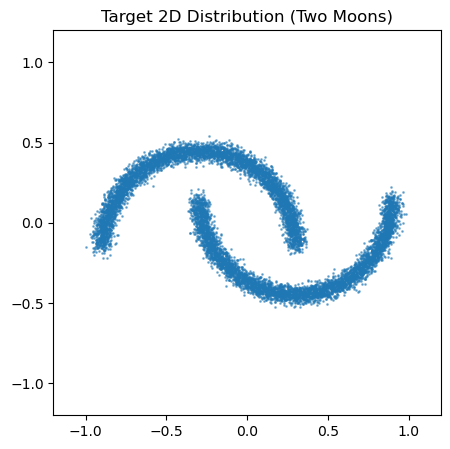

In [2]:
def get_moons_samples(n_samples=10000, noise=0.05):
    # 1. Generate the raw two-moons data
    points, _ = make_moons(n_samples=n_samples, noise=noise, random_state=42)
    
    # 2. Center the data (mean = 0)
    points = points - np.mean(points, axis=0)
    
    # 3. Scale the data to roughly the [-1, 1] range
    points = points / np.max(np.abs(points))
    
    return torch.from_numpy(points).float()

moons_data = get_moons_samples(10000, noise=0.05).to(device)

# Plot the Two Moons
plt.figure(figsize=(5,5))
plt.scatter(moons_data[:, 0].cpu(), moons_data[:, 1].cpu(), s=1, alpha=0.5)
plt.title("Target 2D Distribution (Two Moons)")
plt.xlim(-1.2, 1.2); plt.ylim(-1.2, 1.2)
plt.show()

# --- MNIST Dataset ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Map to [-1, 1]
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True)

### Noise Schedules

The forward process adds noise according to a variance schedule $\beta_t$. 
Let's define Linear and Cosine schedules and interactively observe how they destroy our 2D data!
You may also look into implementing your own schedule, Sigmoid schedule is quite popular.

In [3]:
def get_beta_schedule(schedule_type, num_timesteps):
    if schedule_type == 'linear':
        scale = 1000 / num_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        return torch.linspace(beta_start, beta_end, num_timesteps)
    elif schedule_type == 'cosine':
        steps = num_timesteps + 1
        s = 0.008
        t = torch.linspace(0, num_timesteps, steps)
        alphas_cumprod = torch.cos(((t / num_timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0, 0.999)

def plot_forward_process(schedule_type, timestep):
    T = 100
    betas = get_beta_schedule(schedule_type, T)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    if timestep == 0:
        x_t = moons_data.cpu()
    else:
        alpha_bar_t = alphas_cumprod[timestep-1]
        noise = torch.randn_like(moons_data)
        x_t = torch.sqrt(alpha_bar_t) * moons_data + torch.sqrt(1 - alpha_bar_t) * noise
        
    plt.figure(figsize=(5,5))
    plt.scatter(x_t[:, 0].cpu(), x_t[:, 1].cpu(), s=1, alpha=0.3)
    plt.xlim(-3, 3); plt.ylim(-3, 3)
    plt.title(f"Schedule: {schedule_type} | Timestep: {timestep}/{T}")
    plt.show()

widgets.interact(plot_forward_process, 
                 schedule_type=widgets.Dropdown(options=['linear', 'cosine'], value='linear'),
                 timestep=widgets.IntSlider(min=0, max=100, step=1, value=0));

interactive(children=(Dropdown(description='schedule_type', options=('linear', 'cosine'), value='linear'), Int…

### Architecture

The architecture for our 2D diffusion model is defined below. Notice that we defined `SinusoidalPositionEmbeddings`. The purpose of it is to enmbed the time depending on where we are in the diffusion process. It is standard practice even in state of the art image generation models (although more advanced positional embeddings like ROPE are used).

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class VBEDiffusionModel(nn.Module):
    def __init__(self, data_dim=2, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.net = nn.Sequential(
            nn.Linear(data_dim + hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, data_dim * 2) 
        )
        
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x_input = torch.cat([x, t_emb], dim=-1)
        out = self.net(x_input)
        mu, log_var = torch.chunk(out, 2, dim=-1)
        return mu, log_var

### Loss
Unlike typical DDPMs that predict the noise $\epsilon$ and assume fixed variance, our network will directly predict:
1. The mean $\mu_\theta(x_t, t)$
2. The log-variance $\log \Sigma_\theta(x_t, t)$ [Optional, this is fixed otherwise]

We optimize the Variational Lower Bound. At step $t$, the loss is the KL divergence between two Gaussians:
$$L_t = D_{KL}(q(x_{t-1}|x_t, x_0) || p_\theta(x_{t-1}|x_t))$$

For two Gaussians $q(\mu_1, \sigma_1^2)$ and $p(\mu_2, \sigma_2^2)$, the KL divergence is:
$$\frac{1}{2} \left[ \log\frac{\sigma_2^2}{\sigma_1^2} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{\sigma_2^2} - 1 \right]$$

In [5]:
def compute_exact_kl_loss(model, x_0, t, betas, learn_variance=True):
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    alpha_t = alphas[t].view(-1, 1)
    alpha_bar_t = alphas_cumprod[t].view(-1, 1)
    alpha_bar_prev = alphas_cumprod_prev[t].view(-1, 1)
    beta_t = betas[t].view(-1, 1)
    
    # 1. Forward process: Sample x_t
    noise = torch.randn_like(x_0)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    
    # 2. True posterior q(x_{t-1} | x_t, x_0)
    true_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * x_0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
    
    true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
    true_log_var = torch.log(torch.clamp(true_var, min=1e-20))
    
    # 3. Model prediction (predicting x_0 for stability, and log_var directly)
    pred_x0, pred_log_var_model = model(x_t, t)
    
    # Analytically construct the predicted mean from the predicted x_0
    pred_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * pred_x0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
    
    # Toggle variance learning
    if learn_variance:
        pred_log_var = pred_log_var_model
    else:
        pred_log_var = true_log_var.detach() # Force exact analytical variance
    
    # 4. Exact KL Divergence Formula
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    
    return kl.mean()

### Training with and without learnt log-variance on 2-moons

Training Two Moons. Learning Variance: False
Epoch 0 | Loss: 1.7789
Epoch 2000 | Loss: 0.0114
Epoch 4000 | Loss: 0.0186
Epoch 6000 | Loss: 0.0106
Epoch 8000 | Loss: 0.0150


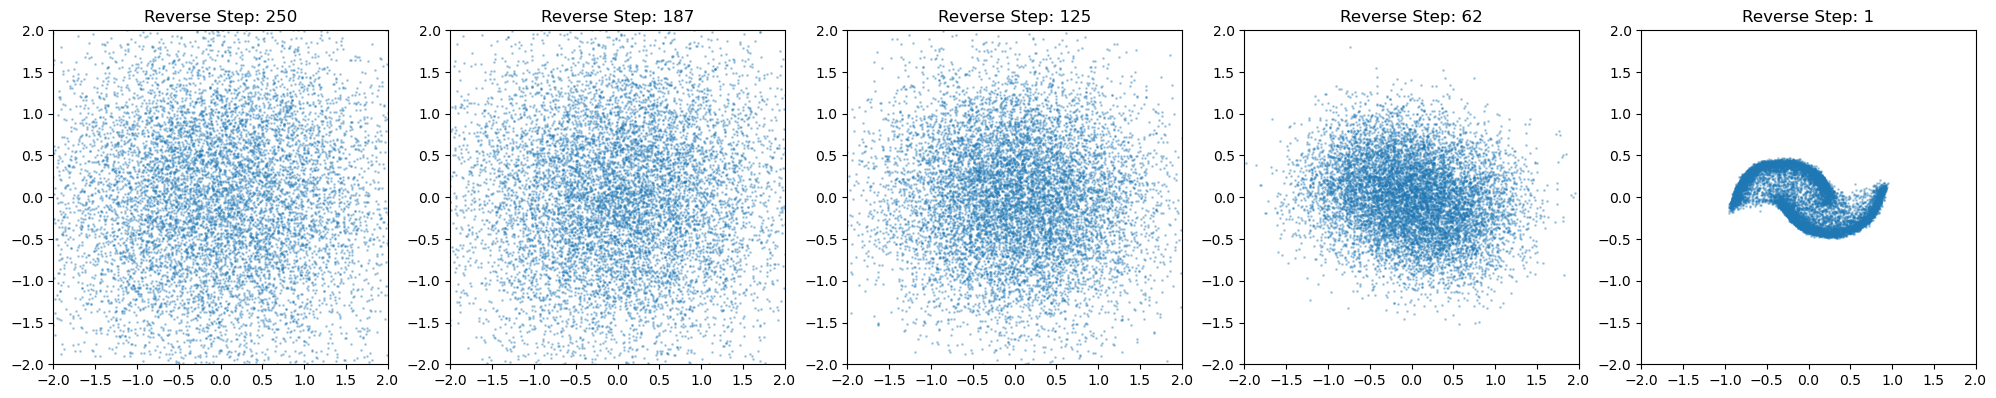

Training Two Moons. Learning Variance: True
Epoch 0 | Loss: 0.0165
Epoch 2000 | Loss: 0.0157
Epoch 4000 | Loss: 0.0126
Epoch 6000 | Loss: 0.0105
Epoch 8000 | Loss: 0.0100


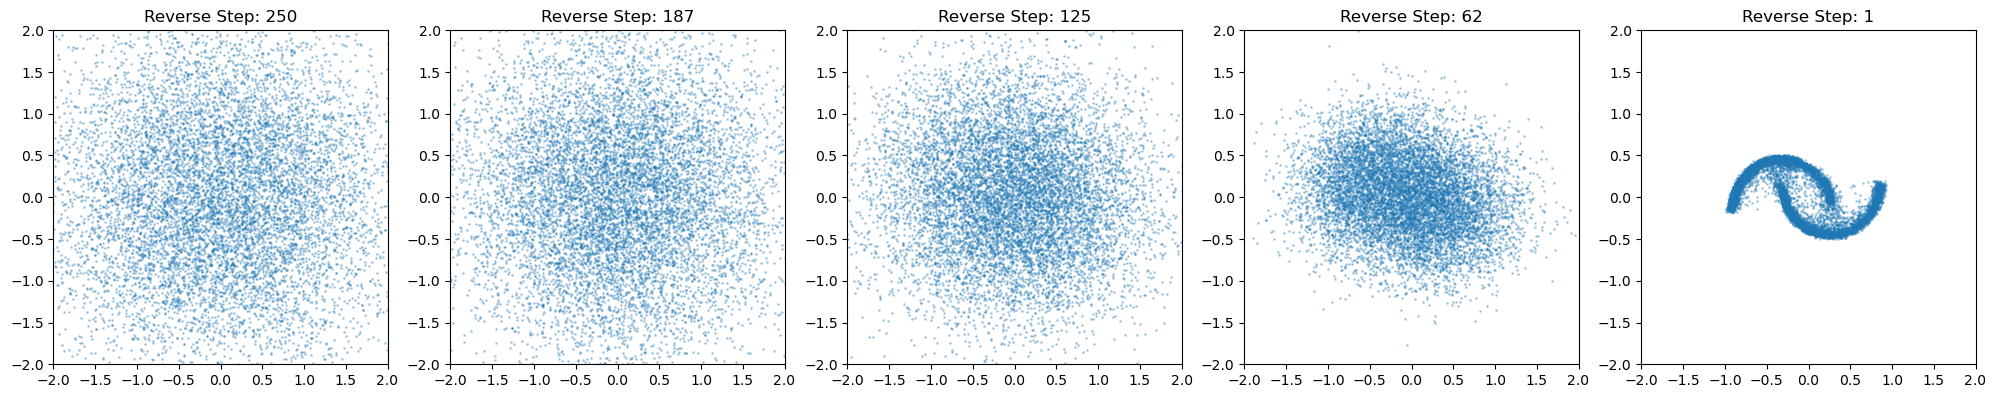

In [6]:
# Setup Model
T = 250
betas = get_beta_schedule('cosine', T).to(device)
model_2d = VBEDiffusionModel(data_dim=2).to(device)
optimizer = torch.optim.Adam(model_2d.parameters(), lr=1e-3)

for LEARN_VARIANCE in [False, True]:
    epochs = 10000
    batch_size = 512

    model_2d.train()
    print(f"Training Two Moons. Learning Variance: {LEARN_VARIANCE}")
    for epoch in range(epochs):
        idx = torch.randint(0, len(moons_data), (batch_size,))
        x_0 = moons_data[idx]
        
        t = torch.randint(1, T, (batch_size,), device=device)
        loss = compute_exact_kl_loss(model_2d, x_0, t, betas)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_2d.parameters(), 1.0)
        optimizer.step()
        
        if epoch % 2000 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    @torch.no_grad()
    def plot_reverse_process(model, betas, T, num_samples=10000, learn_variance=True):
        model.eval()
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        x_t = torch.randn(num_samples, 2, device=device)
        history = [(T, x_t.cpu().numpy())]
        
        for t in reversed(range(1, T)):
            t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
            
            # Predict x_0 from the model
            pred_x0, pred_log_var = model(x_t, t_tensor)
            
            alpha_t = alphas[t]
            alpha_bar_t = alphas_cumprod[t]
            alpha_bar_prev = alphas_cumprod_prev[t]
            beta_t = betas[t]
            
            # Calculate true variance analytically
            true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
            
            if not learn_variance:
                pred_log_var = torch.log(torch.clamp(true_var, min=1e-20))
                
            # Construct pred_mu analytically from predicted x_0
            pred_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * pred_x0 + \
                    (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
                
            noise = torch.randn_like(x_t) if t > 1 else torch.zeros_like(x_t)
            x_t = pred_mu + torch.exp(0.5 * pred_log_var) * noise
            
            if t == int(T * 0.75) or t == int(T * 0.5) or t == int(T * 0.25) or t == 1:
                history.append((t, x_t.cpu().numpy()))
                
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        for i, (step, points) in enumerate(history):
            axes[i].scatter(points[:, 0], points[:, 1], s=1, alpha=0.3)
            axes[i].set_title(f"Reverse Step: {step}")
            axes[i].set_xlim(-2, 2); axes[i].set_ylim(-2, 2)
            axes[i].set_aspect('equal')
        plt.tight_layout()
        plt.show()

    plot_reverse_process(model_2d, betas, T, learn_variance=LEARN_VARIANCE)

### 2D Spatial Diffusion (MNIST)
Now we move from 2D coordinates to 2D image grids (1x28x28 pixels). We will use a lightweight U-Net architecture. 

To parameterize $p_\theta(x_{t-1}|x_t) = \mathcal{N}(\mu_\theta, \Sigma_\theta)$, our U-Net takes in a noisy 1-channel image and the current timestep $t$. The final convolutional layer outputs **2 channels**. We slice this output in half: channel 0 is our predicted mean, and channel 1 is our predicted log-variance.

The results will likely not be very good as the number of parameters is too small in order to accommodate CPU training. If you have access to a GPU, increase embedding dimensions and epochs for good samples!

In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Maps the scalar timestep t into a high-dimensional vector."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class SimpleConvBlock(nn.Module):
    """A basic convolutional block with time embedding injection."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn = nn.GroupNorm(4, out_ch) # GroupNorm is more stable than BatchNorm for small batches
        self.relu = nn.GELU()

    def forward(self, x, t_emb):
        # First convolution
        h = self.relu(self.bn(self.conv1(x)))
        
        # Inject time embedding
        time_emb = self.relu(self.time_mlp(t_emb))
        # Reshape time_emb to match spatial dimensions (B, C, 1, 1)
        time_emb = time_emb.unsqueeze(-1).unsqueeze(-1)
        h = h + time_emb
        
        # Second convolution
        h = self.relu(self.bn(self.conv2(h)))
        return h

class MicroConvBlock(nn.Module):
    """An ultra-lightweight conv block for CPU training."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.GELU()

    def forward(self, x, t_emb):
        h = self.relu(self.bn(self.conv(x)))
        # Add time embedding as a bias across the channel dimension
        return h + t_emb.view(-1, h.shape[1], 1, 1)

class Micro_UNet_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        # Increased channel counts to give the model actual learning capacity
        ch1, ch2, ch3 = 16, 32, 64 
        
        # Time embedding: map scalar t to the max channel dimensions we need
        self.time_mlp = nn.Sequential(
            nn.Linear(1, 32),
            nn.GELU(),
            nn.Linear(32, 64) 
        )
        
        # Downsample
        self.down1 = MicroConvBlock(1, ch1)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = MicroConvBlock(ch1, ch2)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = MicroConvBlock(ch2, ch3)
        
        # Upsample (using nearest neighbor to save CPU cycles over ConvTranspose)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_conv1 = MicroConvBlock(ch3 + ch2, ch2)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_conv2 = MicroConvBlock(ch2 + ch1, ch1)
        
        # Output 2 channels (Mean and Log-Variance)
        self.final_conv = nn.Conv2d(ch1, 2, kernel_size=1)

    def forward(self, x, t):
        # Time embedding
        t_float = t.unsqueeze(1).float() / 100.0
        t_emb = self.time_mlp(t_float)
        
        # Split time embeddings for different channel sizes
        t1, t2, t3 = t_emb[:, :16], t_emb[:, :32], t_emb[:, :64]
        
        # Encoder
        d1 = self.down1(x, t1)
        d2 = self.down2(self.pool1(d1), t2)
        
        # Bottleneck
        b = self.bottleneck(self.pool2(d2), t3)
        
        # Decoder
        u1 = self.up1(b)
        u1 = self.up_conv1(torch.cat([u1, d2], dim=1), t2)
        
        u2 = self.up2(u1)
        u2 = self.up_conv2(torch.cat([u2, d1], dim=1), t1)
        
        out = self.final_conv(u2)
        
        # Split into mean and log-variance
        mu, log_var = torch.chunk(out, 2, dim=1)
        return mu, log_var
    
unet_model = Micro_UNet_MNIST().to(device)
print(f"Total trainable parameters: {sum(p.numel() for p in unet_model.parameters() if p.requires_grad):,}")

Total trainable parameters: 60,434


Because our `compute_kl_loss` function from Section 4 was built purely on PyTorch tensor math, it already handles arbitrary dimensional arrays gracefully! We just need to ensure the dimensions of our `alpha` and `beta` schedules match the 4D image shape `(Batch, Channels, Height, Width)` when we compute the loss.

In [8]:
def compute_image_kl_loss(model, x_0, t, betas, learn_variance=False):
    """Adapted KL Loss to handle (B, C, H, W) shapes with optional variance learning."""
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    alpha_t = alphas[t].view(-1, 1, 1, 1)
    alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)
    alpha_bar_prev = alphas_cumprod_prev[t].view(-1, 1, 1, 1)
    beta_t = betas[t].view(-1, 1, 1, 1)
    
    # 1. Forward process: Sample x_t
    noise = torch.randn_like(x_0)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    
    # 2. True posterior q(x_{t-1} | x_t, x_0)
    true_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * x_0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
    
    true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
    true_log_var = torch.log(torch.clamp(true_var, min=1e-20))
    
    # 3. Model prediction (Predict x_0 and raw variance output)
    pred_x0, pred_var_out = model(x_t, t)
    
    # Analytically construct pred_mu using predicted x_0
    pred_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * pred_x0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
              
    if learn_variance:
        min_log_var = true_log_var.detach()
        max_log_var = torch.log(beta_t).detach()
        # Bound the network's output to act as an interpolation fraction
        frac = torch.clamp((pred_var_out + 1.0) / 2.0, min=0.0, max=1.0)
        pred_log_var = frac * max_log_var + (1.0 - frac) * min_log_var
    else:
        # Force the model to use the exact mathematical variance
        pred_log_var = true_log_var.detach()
    
    # 4. KL Divergence
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    
    return kl.mean()

In [9]:
# Setup Training
epochs_mnist = 3 # Keep it low for CPU, increase to 50+ if on GPU
T = 250          # Total diffusion steps
betas = get_beta_schedule('cosine', T).to(device)
optimizer_unet = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

unet_model.train()
print("Starting U-Net Training on MNIST...")

for epoch in range(epochs_mnist):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(mnist_loader):
        images = images.to(device)
        batch_size = images.shape[0]
        
        # Sample random timesteps t in [1, T-1] for the batch
        t = torch.randint(1, T, (batch_size,), device=device)
        
        # Compute exact VLB Loss (KL Divergence)
        loss = compute_image_kl_loss(unet_model, images, t, betas)
        
        # Optimize
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        
        total_loss += loss.item()
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs_mnist} | Batch {batch_idx}/{len(mnist_loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(mnist_loader)
    print(f"=== Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f} ===")

Starting U-Net Training on MNIST...
Epoch 1/3 | Batch 0/469 | Loss: 5.8635
Epoch 1/3 | Batch 100/469 | Loss: 0.0242
Epoch 1/3 | Batch 200/469 | Loss: 0.0109
Epoch 1/3 | Batch 300/469 | Loss: 0.0195
Epoch 1/3 | Batch 400/469 | Loss: 0.0233
=== Epoch 1 Completed | Average Loss: 0.1307 ===
Epoch 2/3 | Batch 0/469 | Loss: 0.0039
Epoch 2/3 | Batch 100/469 | Loss: 0.0061
Epoch 2/3 | Batch 200/469 | Loss: 0.0079
Epoch 2/3 | Batch 300/469 | Loss: 0.0097
Epoch 2/3 | Batch 400/469 | Loss: 0.0088
=== Epoch 2 Completed | Average Loss: 0.0173 ===
Epoch 3/3 | Batch 0/469 | Loss: 0.0305
Epoch 3/3 | Batch 100/469 | Loss: 0.0139
Epoch 3/3 | Batch 200/469 | Loss: 0.0098
Epoch 3/3 | Batch 300/469 | Loss: 0.0180
Epoch 3/3 | Batch 400/469 | Loss: 0.0068
=== Epoch 3 Completed | Average Loss: 0.0133 ===


Let's see what our model learned! To generate a new image, we start with pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$ and iteratively sample from our model $p_\theta(x_{t-1}|x_t)$:

$$x_{t-1} = \mu_\theta(x_t, t) + \exp(0.5 \cdot \log \Sigma_\theta(x_t, t)) \cdot z$$

where $z \sim \mathcal{N}(0, I)$ for $t > 1$, and $z = 0$ at the final step $t = 1$.

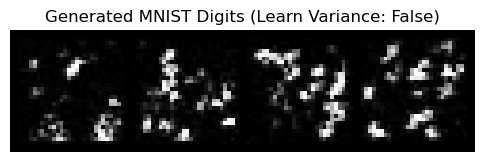

In [10]:
@torch.no_grad()
def sample_and_plot_mnist(model, num_samples=4, learn_variance=False):
    model.eval()
    
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    # 1. Start with pure noise
    x_t = torch.randn(num_samples, 1, 28, 28, device=device)
    
    # 2. Iteratively denoise
    for t in reversed(range(1, T)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        alpha_t = alphas[t].view(-1, 1, 1, 1)
        alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)
        alpha_bar_prev = alphas_cumprod_prev[t].view(-1, 1, 1, 1)
        beta_t = betas[t].view(-1, 1, 1, 1)
        
        # Predict x_0 and raw variance output
        pred_x0, pred_var_out = model(x_t, t_tensor)
        
        # STATIC THRESHOLDING: Crucial for stabilizing x_0 prediction
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)
        
        # Analytically construct pred_mu using the clamped x_0
        pred_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * pred_x0 + \
                  (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
        
        # Calculate Variance Bounds
        true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
        min_log_var = torch.log(torch.clamp(true_var, min=1e-20))
        max_log_var = torch.log(beta_t)
        
        if learn_variance:
            # Decode the model's output as an interpolation fraction
            frac = torch.clamp((pred_var_out + 1.0) / 2.0, min=0.0, max=1.0)
            pred_log_var = frac * max_log_var + (1.0 - frac) * min_log_var
        else:
            # Fall back to the mathematical minimum variance
            pred_log_var = min_log_var
        
        # Reparameterization trick
        z = torch.randn_like(x_t) if t > 1 else torch.zeros_like(x_t)
        x_t = pred_mu + torch.exp(0.5 * pred_log_var) * z

    # 3. Plotting the results
    x_t = x_t.cpu()
    x_t = (x_t + 1) / 2.0  # Scale [-1, 1] back to [0, 1] for plotting
    x_t = torch.clamp(x_t, 0, 1)
    
    grid = torchvision.utils.make_grid(x_t, nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"Generated MNIST Digits (Learn Variance: {learn_variance})")
    plt.show()

# Run inference
sample_and_plot_mnist(unet_model, learn_variance=False)

Starting U-Net Training on MNIST...
Epoch 1/3 | Batch 0/469 | Loss: 0.0118
Epoch 1/3 | Batch 100/469 | Loss: 0.0146
Epoch 1/3 | Batch 200/469 | Loss: 0.0033
Epoch 1/3 | Batch 300/469 | Loss: 0.0058
Epoch 1/3 | Batch 400/469 | Loss: 0.0328
=== Epoch 1 Completed | Average Loss: 0.0153 ===
Epoch 2/3 | Batch 0/469 | Loss: 0.0028
Epoch 2/3 | Batch 100/469 | Loss: 0.0046
Epoch 2/3 | Batch 200/469 | Loss: 0.0108
Epoch 2/3 | Batch 300/469 | Loss: 0.0073
Epoch 2/3 | Batch 400/469 | Loss: 0.0037
=== Epoch 2 Completed | Average Loss: 0.0077 ===
Epoch 3/3 | Batch 0/469 | Loss: 0.0126
Epoch 3/3 | Batch 100/469 | Loss: 0.0027
Epoch 3/3 | Batch 200/469 | Loss: 0.0094
Epoch 3/3 | Batch 300/469 | Loss: 0.0035
Epoch 3/3 | Batch 400/469 | Loss: 0.0086
=== Epoch 3 Completed | Average Loss: 0.0074 ===


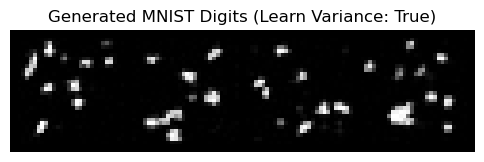

In [11]:
# Setup Training
epochs_mnist = 3 # Keep it low for CPU, increase to 50+ if on GPU
T = 250          # Total diffusion steps
betas = get_beta_schedule('cosine', T).to(device)
optimizer_unet = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

unet_model.train()
print("Starting U-Net Training on MNIST...")

for epoch in range(epochs_mnist):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(mnist_loader):
        images = images.to(device)
        batch_size = images.shape[0]
        
        # Sample random timesteps t in [1, T-1] for the batch
        t = torch.randint(1, T, (batch_size,), device=device)
        
        # Compute exact VLB Loss (KL Divergence)
        loss = compute_image_kl_loss(unet_model, images, t, betas, learn_variance=True)
        
        # Optimize
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        
        total_loss += loss.item()
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs_mnist} | Batch {batch_idx}/{len(mnist_loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(mnist_loader)
    print(f"=== Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f} ===")

sample_and_plot_mnist(unet_model, learn_variance=True)

### Non-Gaussian Noising: The Blurring Process

Standard diffusion models rely entirely on adding Gaussian noise. But because we have formulated our model strictly as a Hierarchical VAE, we can define our forward process $q$ by other means—like blurring or fading—without changing our objective function! 

Here, we simulate a process that relies heavily on deterministic decay (fading/blurring the signal) with only a tiny fraction of noise added for mathematical stability. We simply reshape our schedules to broadcast across the `(B, C, H, W)` image dimensions.

We visualize the noising processes of the two in the figure below. In the first row it is Gaussian diffusion and in the second row it is blurring diffusion.

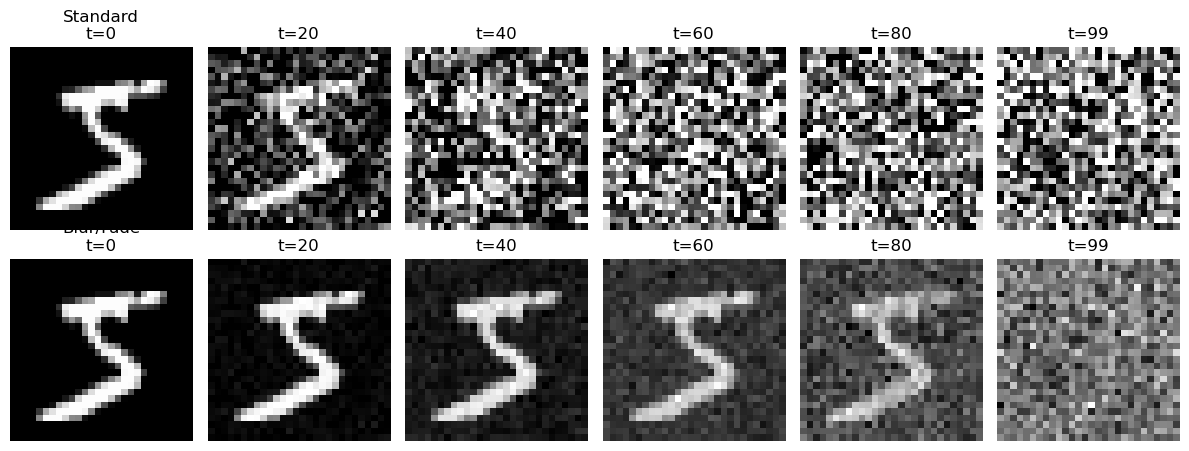

In [12]:
# We'll visualize over 100 timesteps, plotting 6 distinct frames
T = 100
betas = get_beta_schedule('linear', T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Grab a single image from the MNIST dataset
img_tensor, label = mnist_dataset[0] 
x_0 = img_tensor.unsqueeze(0).to(device) 

timesteps_to_show = [0, 20, 40, 60, 80, 99]
num_frames = len(timesteps_to_show)

fig, axes = plt.subplots(2, num_frames, figsize=(2 * num_frames, 4.5))

for i, t_val in enumerate(timesteps_to_show):
    if t_val == 0:
        # t=0 is the clean image for both processes
        x_t_std = x_0
        x_t_blur = x_0
    else:
        t = torch.tensor([t_val], device=device)
        noise = torch.randn_like(x_0)
        
        # --- 1. Standard Diffusion Forward Process ---
        alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)
        x_t_std = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
        
        # --- 2. Blur Diffusion Forward Process ---
        a_t = torch.cos((t.float() / T) * (torch.pi / 2)).view(-1, 1, 1, 1)
        b_t = (betas[t] * 0.1).view(-1, 1, 1, 1)
        x_t_blur = a_t * x_0 + torch.sqrt(b_t) * noise
        
    # Helper function to convert the [-1, 1] tensor back to [0, 1] for plotting
    def format_for_plot(tensor_img):
        img = tensor_img.squeeze().cpu()
        img = (img + 1.0) / 2.0 
        return torch.clamp(img, 0, 1).numpy()
        
    # Plot Standard Diffusion (Row 0)
    ax_std = axes[0, i]
    ax_std.imshow(format_for_plot(x_t_std), cmap='gray')
    ax_std.axis('off')
    if i == 0:
        ax_std.set_title(f"Standard\nt={t_val}")
    else:
        ax_std.set_title(f"t={t_val}")
        
    # Plot Blur Diffusion (Row 1)
    ax_blur = axes[1, i]
    ax_blur.imshow(format_for_plot(x_t_blur), cmap='gray')
    ax_blur.axis('off')
    if i == 0:
        ax_blur.set_title(f"Blur/Fade\nt={t_val}")
    else:
        ax_blur.set_title(f"t={t_val}")

plt.tight_layout()
plt.show()

In [ ]:
def compute_image_blur_kl_loss(model, x_0, t, betas, learn_variance=False):
    """Computes exact KL divergence for a custom blur forward process with optional variance learning."""
    max_t = len(betas)
    
    a_t = torch.cos((t.float() / max_t) * (torch.pi / 2)).view(-1, 1, 1, 1)
    b_t = (betas[t] * 0.1).view(-1, 1, 1, 1) 
    
    t_prev = (t - 1).clamp(min=0)
    a_prev = torch.cos((t_prev.float() / max_t) * (torch.pi / 2)).view(-1, 1, 1, 1)
    b_prev = (betas[t_prev] * 0.1).view(-1, 1, 1, 1)

    # 1. Forward process: Sample x_t
    noise = torch.randn_like(x_0)
    x_t = a_t * x_0 + torch.sqrt(b_t) * noise
    
    # 2. True posterior q(x_{t-1} | x_t, x_0)
    var_t_given_prev = b_t - (a_t/a_prev)**2 * b_prev 
    var_t_given_prev = torch.clamp(var_t_given_prev, min=1e-20)
    
    true_var = 1.0 / (1.0/var_t_given_prev + 1.0/torch.clamp(b_prev, min=1e-20))
    true_mu = true_var * ( x_t / var_t_given_prev + (a_prev * x_0) / torch.clamp(b_prev, min=1e-20) )
    true_log_var = torch.log(torch.clamp(true_var, min=1e-20))
    
    # 3. Model prediction (Predict x_0 and raw variance output)
    pred_x0, pred_var_out = model(x_t, t)
    
    # Analytically construct pred_mu using predicted x_0
    pred_mu = true_var * ( x_t / var_t_given_prev + (a_prev * pred_x0) / torch.clamp(b_prev, min=1e-20) )
    
    if learn_variance:
        min_log_var = true_log_var.detach()
        max_log_var = torch.log(torch.clamp(b_t, min=1e-20)).detach()
        frac = torch.clamp((pred_var_out + 1.0) / 2.0, min=0.0, max=1.0)
        pred_log_var = frac * max_log_var + (1.0 - frac) * min_log_var
    else:
        pred_log_var = true_log_var.detach()
    
    # 4. KL Divergence 
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    
    return kl.mean()

In [15]:
# Setup Training
epochs_mnist = 3 # Keep it low for CPU, increase to 50+ if on GPU
T = 250          # Total diffusion steps
betas = get_beta_schedule('cosine', T).to(device)
optimizer_unet = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

unet_model.train()
print("Starting U-Net Training on MNIST...")

for epoch in range(epochs_mnist):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(mnist_loader):
        images = images.to(device)
        batch_size = images.shape[0]
        
        # Sample random timesteps t in [1, T-1] for the batch
        t = torch.randint(1, T, (batch_size,), device=device)
        
        # Compute exact blur Loss (KL Divergence)
        loss = compute_image_blur_kl_loss(unet_model, images, t, betas, learn_variance=True)
        
        # Optimize
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        
        total_loss += loss.item()
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs_mnist} | Batch {batch_idx}/{len(mnist_loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(mnist_loader)
    print(f"=== Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f} ===")

Starting U-Net Training on MNIST...
Epoch 1/3 | Batch 0/469 | Loss: 0.6461
Epoch 1/3 | Batch 100/469 | Loss: 0.1456
Epoch 1/3 | Batch 200/469 | Loss: 0.0901
Epoch 1/3 | Batch 300/469 | Loss: 0.0862
Epoch 1/3 | Batch 400/469 | Loss: 0.1264
=== Epoch 1 Completed | Average Loss: 0.0956 ===
Epoch 2/3 | Batch 0/469 | Loss: 0.0260
Epoch 2/3 | Batch 100/469 | Loss: 0.0495
Epoch 2/3 | Batch 200/469 | Loss: 0.0455
Epoch 2/3 | Batch 300/469 | Loss: 0.0364
Epoch 2/3 | Batch 400/469 | Loss: 0.0169
=== Epoch 2 Completed | Average Loss: 0.0390 ===
Epoch 3/3 | Batch 0/469 | Loss: 0.0234
Epoch 3/3 | Batch 100/469 | Loss: 0.0401
Epoch 3/3 | Batch 200/469 | Loss: 0.0422
Epoch 3/3 | Batch 300/469 | Loss: 0.0233
Epoch 3/3 | Batch 400/469 | Loss: 0.0287
=== Epoch 3 Completed | Average Loss: 0.0341 ===


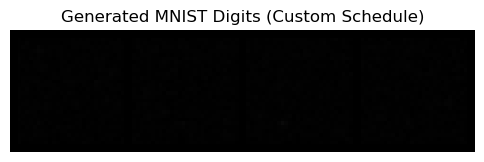

In [18]:
@torch.no_grad()
def sample_and_plot_custom(model, betas, T, num_samples=4, learn_variance=False):
    model.eval()
    device = next(model.parameters()).device
    max_t = len(betas)
    
    # 1. Start with noise scaled to match the max variance of your schedule
    # At t=T, b_t is roughly betas[-1] * 0.1
    initial_std = math.sqrt(betas[-1].item() * 0.1)
    x_t = torch.randn(num_samples, 1, 28, 28, device=device) * initial_std
    
    # 2. Iteratively denoise
    for t in reversed(range(1, T)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        # Recreate your custom schedule for timestep t
        a_t = torch.cos((t_tensor.float() / max_t) * (torch.pi / 2)).view(-1, 1, 1, 1)
        b_t = (betas[t_tensor] * 0.1).view(-1, 1, 1, 1) 
        
        t_prev = (t_tensor - 1).clamp(min=0)
        a_prev = torch.cos((t_prev.float() / max_t) * (torch.pi / 2)).view(-1, 1, 1, 1)
        b_prev = (betas[t_prev] * 0.1).view(-1, 1, 1, 1)

        # Calculate exact true variance variables
        var_t_given_prev = b_t - (a_t/a_prev)**2 * b_prev 
        var_t_given_prev = torch.clamp(var_t_given_prev, min=1e-20)
        true_var = 1.0 / (1.0/var_t_given_prev + 1.0/torch.clamp(b_prev, min=1e-20))
        
        # Predict x_0 and raw variance output
        pred_x0, pred_var_out = model(x_t, t_tensor)
        
        # STATIC THRESHOLDING: Mandatory for direct x_0 prediction stability
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)
        
        # Analytically construct pred_mu using the clamped x_0
        pred_mu = true_var * ( x_t / var_t_given_prev + (a_prev * pred_x0) / torch.clamp(b_prev, min=1e-20) )
        
        # Handle Variance Output
        min_log_var = torch.log(torch.clamp(true_var, min=1e-20))
        max_log_var = torch.log(torch.clamp(b_t, min=1e-20))
        
        if learn_variance:
            frac = torch.clamp((pred_var_out + 1.0) / 2.0, min=0.0, max=1.0)
            pred_log_var = frac * max_log_var + (1.0 - frac) * min_log_var
        else:
            pred_log_var = min_log_var
            
        # Reparameterization trick
        z = torch.randn_like(x_t) if t > 1 else torch.zeros_like(x_t)
        x_t = pred_mu + torch.exp(0.5 * pred_log_var) * z

    # 3. Plotting the results
    x_t = x_t.cpu()
    x_t = (x_t + 1) / 2.0  # Scale [-1, 1] back to [0, 1]
    x_t = torch.clamp(x_t, 0, 1)
    
    grid = torchvision.utils.make_grid(x_t, nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.axis('off')
    plt.title("Generated MNIST Digits (Custom Schedule)")
    plt.show()

sample_and_plot_custom(unet_model, betas, T, learn_variance=True)